In [18]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

root = Path("/scratch/s4636708/aida/derived/martini")

# the galaxy to look at
redshift = "z3"
model = "vSIDM"
sub_id = 1176

In [19]:
gal = root / redshift / model / f"gal_{sub_id:06d}"
info = json.load(open(gal / "info.json"))

# 1. cube centre: the velocity in the middle of the cube's velocity axis
#    (MARTINI puts the velocity of the whole subhalo there; it is the same for every galaxy)
h = fits.getheader(gal / "cube.fits")
middle = (h["NAXIS3"] + 1) / 2
v_cube = (h["CRVAL3"] + (middle - h["CRPIX3"]) * h["CDELT3"]) / 1000 # m/s -> km/s
channel = abs(h["CDELT3"]) / 1000 # channel width, km/s

# 2. BBarolo's starting values. VSYS: the middle of the galaxy's total spectrum, from the first
#    (biggest) source in detections.txt, column "Vsys". VROT and INC: from our bbarolo.par
for line in open(gal / "bbarolo" / "detections.txt"):
    if line.strip() and not line.startswith("#"):
        v_start = float(line.split()[12])
        break
for line in open(gal / "bbarolo" / "bbarolo.par"):
    if line.startswith("VROT"):
        vrot_start = float(line.split()[1])
    if line.startswith("INC"):
        inc = float(line.split()[1])

# 3. fitted values. First stage: VSYS and VROT for every ring. Second stage: one VSYS for all rings
stage1 = np.loadtxt(gal / "bbarolo" / "rings_final1.txt")
stage2 = np.loadtxt(gal / "bbarolo" / "rings_final2.txt")
radius = stage1[:, 1]   # arcsec
vrot1 = stage1[:, 2]
vsys1 = stage1[:, 11]
vrot2 = stage2[:, 2]
vsys2 = stage2[0, 11]

print("cube centre:", v_cube)
print("BBarolo starting VSYS:", v_start, "   starting VROT:", vrot_start)
print("first stage VSYS, ring by ring:", np.round(vsys1))
print("second stage VSYS:", vsys2)

# the second-stage VSYS is the median over all rings; the rings BBarolo skipped (hole rings) keep the starting value
n_skipped = info["nradii"] - len(vsys1)
print("median check:", np.median(np.concatenate([vsys1, np.full(n_skipped, v_start)])))

cube centre: 338.70000000002
BBarolo starting VSYS: 673.4    starting VROT: 298.1
first stage VSYS, ring by ring: [459. 454. 589. 802. 823. 829. 805. 778. 753. 766.]
second stage VSYS: 772.008
median check: 772.008


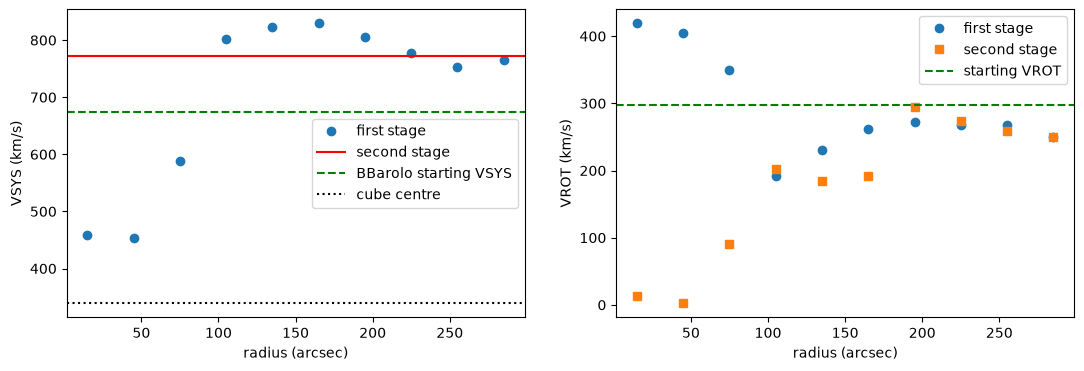

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(radius, vsys1, "o", label="first stage")
ax1.axhline(vsys2, color="red", label="second stage")
ax1.axhline(v_start, color="green", ls="--", label="BBarolo starting VSYS")
ax1.axhline(v_cube, color="black", ls=":", label="cube centre")
ax1.set_xlabel("radius (arcsec)")
ax1.set_ylabel("VSYS (km/s)")
ax1.legend()

ax2.plot(radius, vrot1, "o", label="first stage")
ax2.plot(stage2[:, 1], vrot2, "s", label="second stage")
ax2.axhline(vrot_start, color="green", ls="--", label="starting VROT")
ax2.set_xlabel("radius (arcsec)")
ax2.set_ylabel("VROT (km/s)")
ax2.legend()
plt.show()

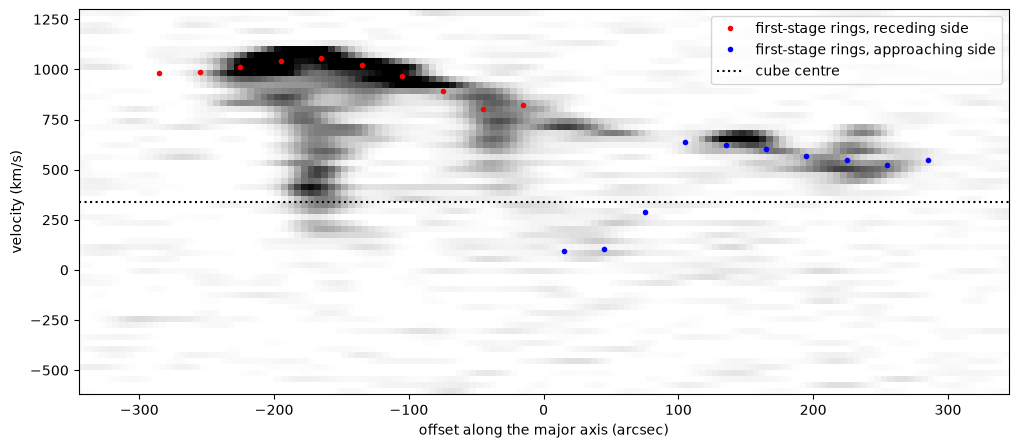

In [21]:
# the data along the major axis (BBarolo's position-velocity slice)
pv_file = gal / "bbarolo" / "pvs" / "MOCK_pv_a.fits"
pv = fits.getdata(pv_file)
hp = fits.getheader(pv_file)
offset = (np.arange(hp["NAXIS1"]) + 1 - hp["CRPIX1"]) * hp["CDELT1"] * 3600                  # deg -> arcsec
velocity = (hp["CRVAL2"] + (np.arange(hp["NAXIS2"]) + 1 - hp["CRPIX2"]) * hp["CDELT2"]) / 1000   # m/s -> km/s

# where each first-stage ring puts its gas on the major axis: VSYS + VROT sin(i) on the receding side
# (negative offsets in these slices) and VSYS - VROT sin(i) on the approaching side (positive offsets)
sin_i = np.sin(np.radians(inc))
plt.figure(figsize=(12, 5))
plt.pcolormesh(offset, velocity, pv, cmap="Greys", vmin=0, vmax=np.nanpercentile(pv, 99))
plt.plot(-radius, vsys1 + vrot1 * sin_i, "r.", label="first-stage rings, receding side")
plt.plot(radius, vsys1 - vrot1 * sin_i, "b.", label="first-stage rings, approaching side")
plt.axhline(v_cube, color="black", ls=":", label="cube centre")
plt.xlabel("offset along the major axis (arcsec)")
plt.ylabel("velocity (km/s)")
plt.legend()
plt.show()

In [5]:
# every galaxy of the sample with a final fit: stellar mass, cube centre (the velocity in the middle
# of the cube's velocity axis) and final VSYS. Reads every cube's header, so it takes a few minutes
names, logm, v_centre, final = [], [], [], []
for info_file in sorted(root.glob("z*/*/gal_*/info.json")):
    info = json.load(open(info_file))
    bb = info_file.parent / "bbarolo"
    if info.get("IsDisc") != 1 or not (bb / "rings_final2.txt").exists():
        continue   # not in the sample, or no final fit
    h = fits.getheader(info_file.parent / "cube.fits")
    middle = (h["NAXIS3"] + 1) / 2
    v_centre.append((h["CRVAL3"] + (middle - h["CRPIX3"]) * h["CDELT3"]) / 1000)   # m/s -> km/s
    names.append(str(info_file.parent.relative_to(root)))
    logm.append(np.log10(info["Mstar"]))
    final.append(np.loadtxt(bb / "rings_final2.txt", ndmin=2)[0, 11])
logm, v_centre, final = np.array(logm), np.array(v_centre), np.array(final)
channel = abs(h["CDELT3"]) / 1000   # channel width, km/s (the same in every cube)
print(len(final), "galaxies")

4073 galaxies


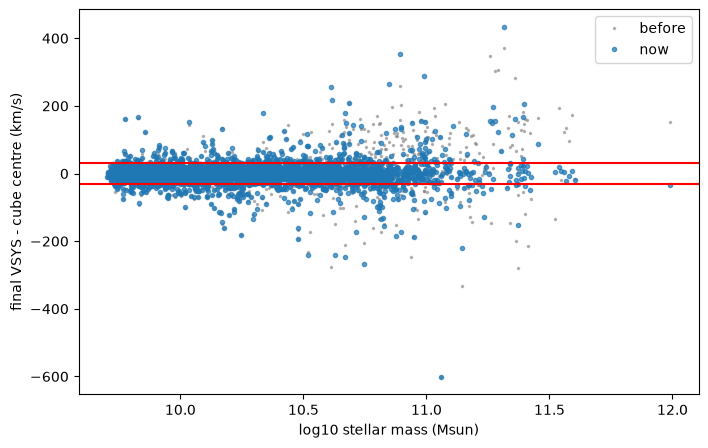

more than one channel from the cube centre: now 641  before 705  of 4073 galaxies
log M* 9.5-10.0: 1296 galaxies, more than one channel off: now 124, before 107
log M* 10.0-10.5: 1768 galaxies, more than one channel off: now 234, before 234
log M* 10.5-11.0:  872 galaxies, more than one channel off: now 220, before 267
log M* 11.0-11.5:  128 galaxies, more than one channel off: now  62, before  90
log M* 11.5-inf:    9 galaxies, more than one channel off: now   1, before   7


In [9]:
# final VSYS of the fits made before the starting VROT came from the stellar mass (28 Sep, start
# 100 km/s for every galaxy), saved to this file before those fits were overwritten
before = {}
for line in open("/home2/s4636708/tmp/vsys_before_vrot0.csv").readlines()[1:]:
    galaxy, vsys = line.strip().split(",")
    before[galaxy] = float(vsys)
final_before = np.array([before.get(g, np.nan) for g in names])

# how far the final VSYS is from the cube centre, against the stellar mass (a rough indicator of
# how fast the galaxy rotates). The red lines are one channel, the velocity resolution of the cube
plt.figure(figsize=(8, 5))
plt.plot(logm, final_before - v_centre, ".", ms=3, color="grey", label="before", alpha=0.5)
plt.plot(logm, final - v_centre, "o", ms=3, color="tab:blue", label="now", alpha=0.7)
plt.axhline(channel, color="red")
plt.axhline(-channel, color="red")
plt.xlabel("log10 stellar mass (Msun)")
plt.ylabel("final VSYS - cube centre (km/s)")
plt.legend()
plt.show()

# how many are more than one channel from the cube centre, in the stellar-mass bins of our mosaics
mass_edges = [9.5, 10.0, 10.5, 11.0, 11.5, np.inf]
off_now = np.abs(final - v_centre) > channel
off_before = np.abs(final_before - v_centre) > channel
print("more than one channel from the cube centre: now", off_now.sum(), " before", off_before.sum(), " of", len(final), "galaxies")
for lo, hi in zip(mass_edges[:-1], mass_edges[1:]):
    sel = (logm >= lo) & (logm < hi)
    print(f"log M* {lo}-{hi}: {sel.sum():4d} galaxies, more than one channel off: now {off_now[sel].sum():3d}, before {off_before[sel].sum():3d}")

In [10]:
# list galaxies furthest from the cube center

print("\nfurthest from the cube centre (now):")
for name, m, v, f in sorted(zip(names, logm, v_centre, final), key=lambda x: abs(x[3] - x[2]), reverse=True)[:10]:
    print(f"{name:30s} logM* {m:4.2f} cube centre {v:7.1f} final VSYS {f:7.1f} diff {f-v:7.1f}")


furthest from the cube centre (now):
z1/CDM/gal_024645              logM* 11.06 cube centre   338.7 final VSYS  -262.9 diff  -601.6
z3/vSIDM/gal_001176            logM* 11.32 cube centre   338.7 final VSYS   772.0 diff   433.3
z1/CDM/gal_039596              logM* 10.89 cube centre   338.7 final VSYS   691.8 diff   353.1
z0.5/CDM/gal_059548            logM* 10.99 cube centre   338.7 final VSYS   627.4 diff   288.7
z1/CDM/gal_036114              logM* 10.75 cube centre   338.7 final VSYS    71.9 diff  -266.8
z0.5/SIDM1/gal_059977          logM* 10.85 cube centre   338.7 final VSYS   604.4 diff   265.7
z1/SIDM1/gal_034962            logM* 10.61 cube centre   338.7 final VSYS   593.9 diff   255.2
z1/CDM/gal_043810              logM* 10.67 cube centre   338.7 final VSYS    93.0 diff  -245.7
z0.5/vSIDM/gal_050729          logM* 10.52 cube centre   338.7 final VSYS    97.4 diff  -241.3
z0.5/vSIDM/gal_064972          logM* 10.63 cube centre   338.7 final VSYS    98.4 diff  -240.3
